In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [2]:
import pandas as pd
df = pd.read_csv('shopkart_sales_dataset.csv')
print("First rows:")
print(df.head())
print("\nLast rows:")
print(df.tail())
print("\nShape:")
print(df.shape)

First rows:
   Order_ID Order_Date  Customer_Age  Gender       City Category  Qty  \
0  SK100001   08-07-24           0.0    Male  Bengaluru   Beauty    5   
1  SK100002   21-03-25         150.0  Female    Lucknow   Beauty    4   
2  SK100003   29-09-24          26.0  Female     Jaipur  Grocery   -2   
3  SK100004   10-02-25          53.0    Male       Pune  Grocery    1   
4  SK100005   10-03-24          33.0  Female      Delhi   Beauty    4   

   Unit Price  Discount  Shipping  Delivery      Sales    Profit  Rating  \
0       37494        25     427.0         4  140602.50  11270.73     4.0   
1       45197         5     288.0         5  171748.60  13467.54     2.0   
2       18665        20     298.0         3   44796.00   2194.68     4.0   
3        5483       120     175.0         9    5208.85    566.00     2.0   
4        1562       -15     465.0        10    6248.00    880.50     4.0   

   Profit_Category  
0                1  
1                1  
2                0  
3       

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         5000 non-null   str    
 1   Order_Date       5000 non-null   str    
 2   Customer_Age     4950 non-null   float64
 3   Gender           4967 non-null   str    
 4   City             5000 non-null   str    
 5   Category         4973 non-null   str    
 6   Qty              5000 non-null   int64  
 7   Unit Price       5000 non-null   int64  
 8   Discount         5000 non-null   int64  
 9   Shipping         4975 non-null   float64
 10  Delivery         5000 non-null   int64  
 11  Sales            5000 non-null   float64
 12  Profit           5000 non-null   float64
 13  Rating           4978 non-null   float64
 14  Profit_Category  5000 non-null   int64  
dtypes: float64(5), int64(5), str(5)
memory usage: 759.3 KB

--- Data Types ---
Order_ID      

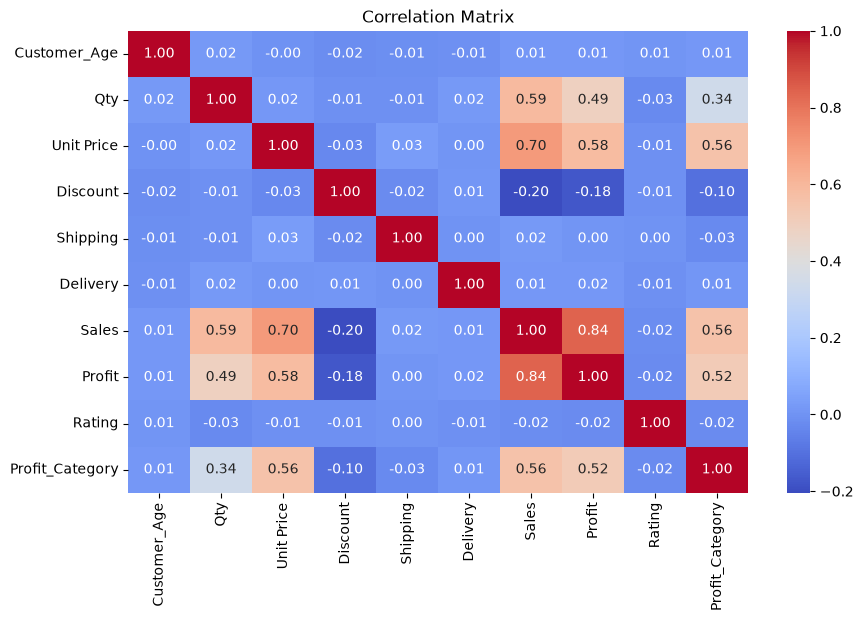

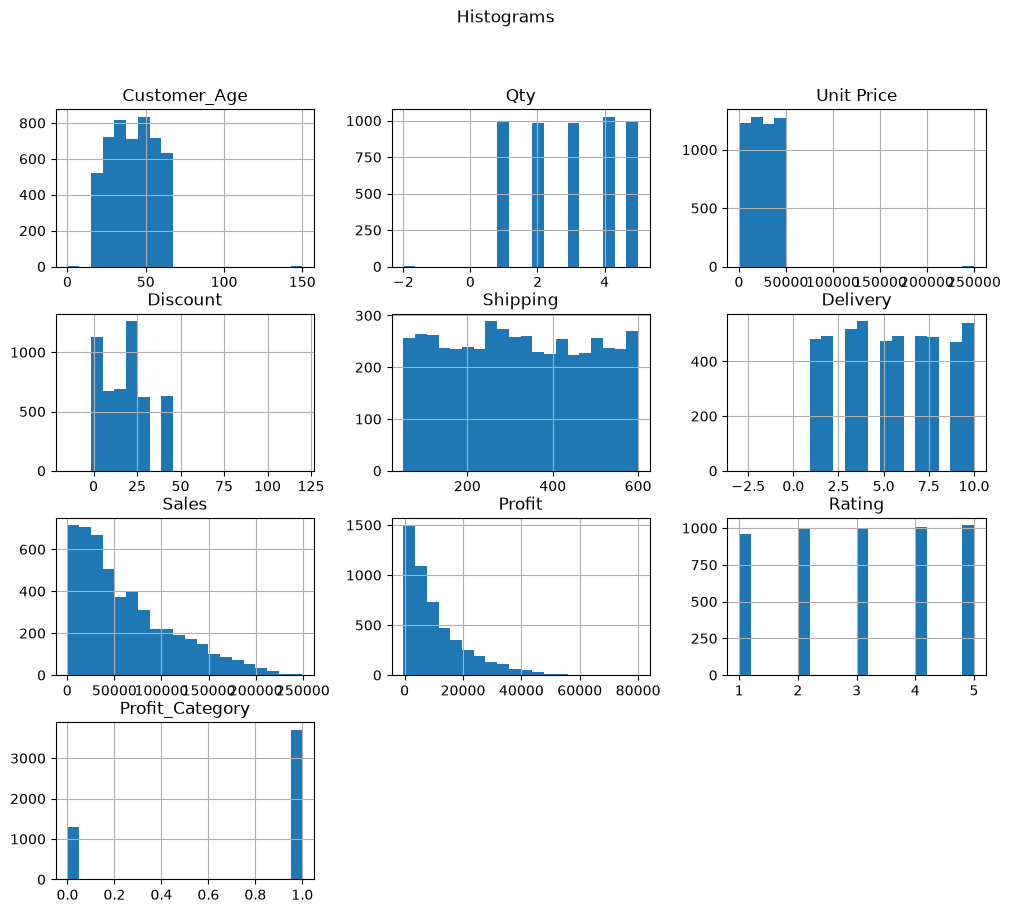

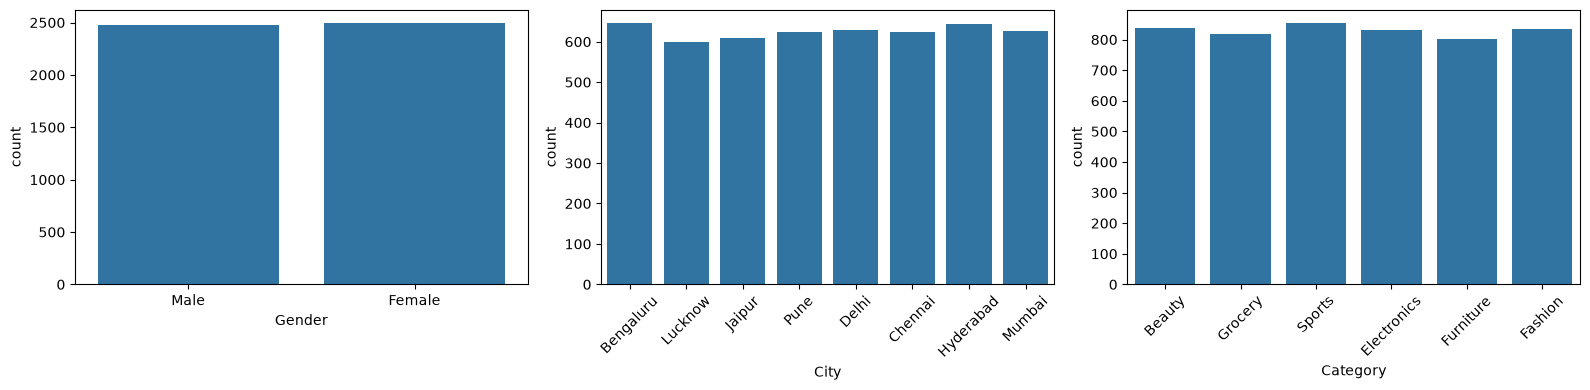

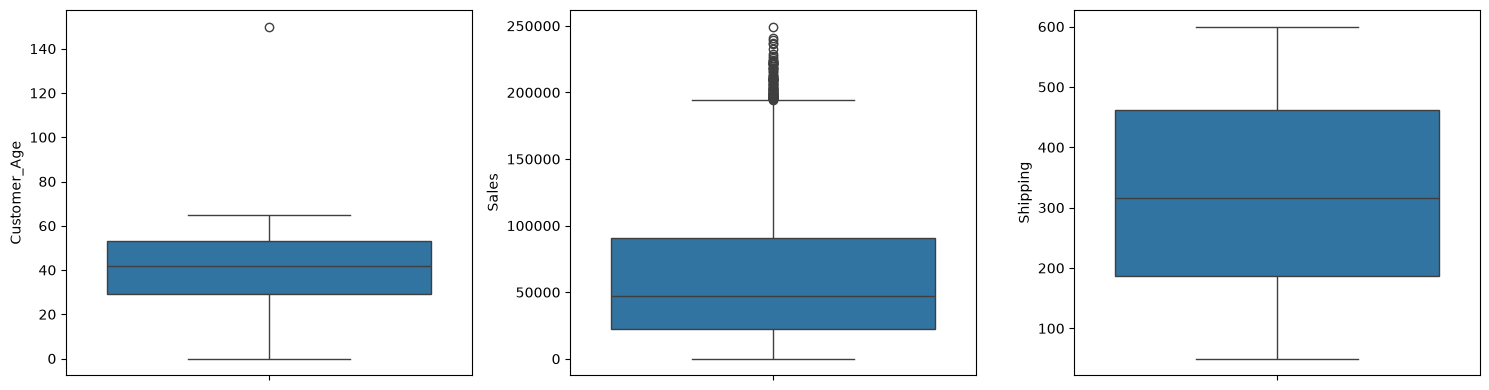

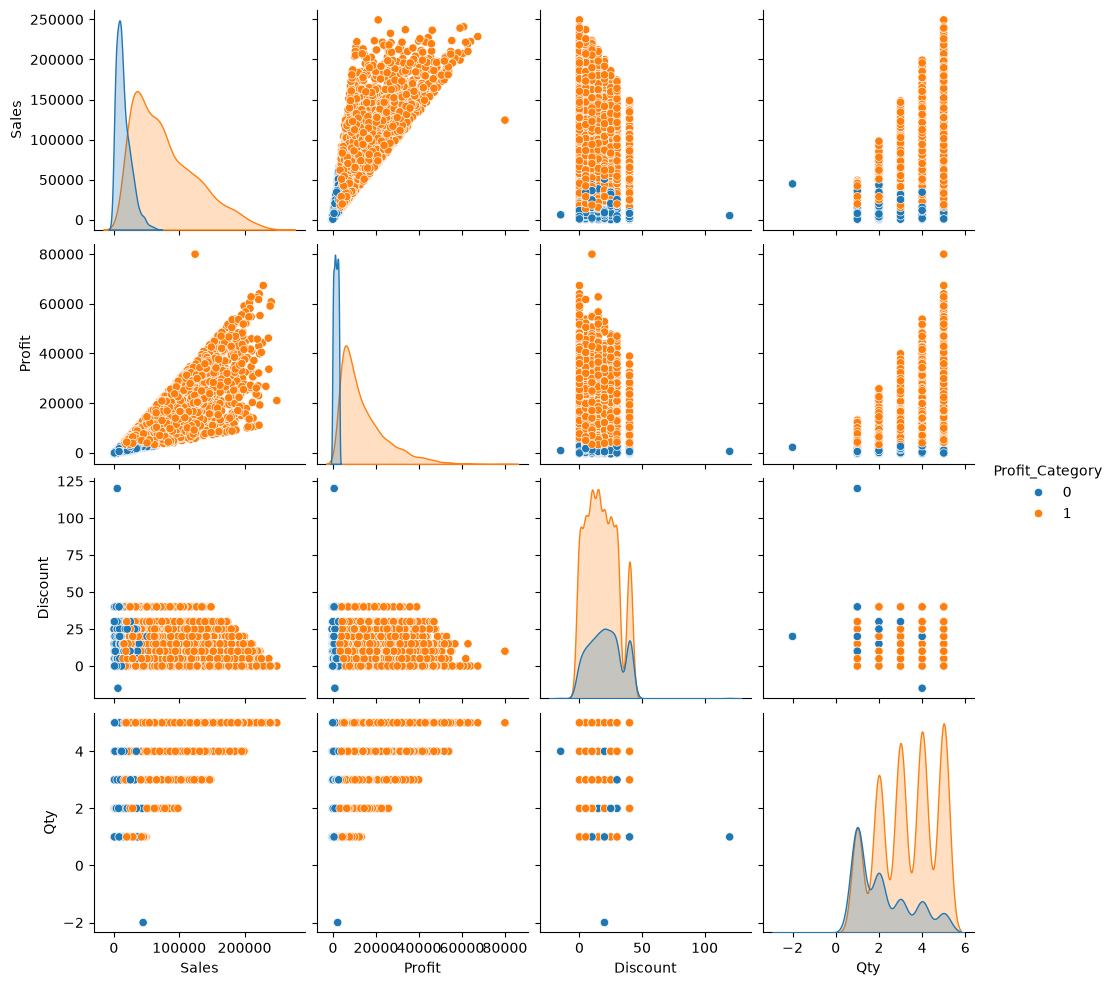

In [3]:
print("--- Dataset Information ---")
df.info()

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Statistical Summary ---")
print(df.describe())

print("\n--- Value Counts ---")
for col in ["Gender", "City", "Category"]:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts(dropna=False))

print("\n--- Class Balance ---")
print(df["Profit_Category"].value_counts(normalize=True))

plt.figure(figsize=(10, 6))
sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Histograms")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x="Gender", ax=axes[0])
sns.countplot(data=df, x="City", ax=axes[1])
sns.countplot(data=df, x="Category", ax=axes[2])
axes[1].tick_params(axis="x", rotation=45)
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, y="Customer_Age", ax=axes[0])
sns.boxplot(data=df, y="Sales", ax=axes[1])
sns.boxplot(data=df, y="Shipping", ax=axes[2])
plt.tight_layout()
plt.show()

selected_cols = ["Sales", "Profit", "Discount", "Qty", "Profit_Category"]
sns.pairplot(df[selected_cols], hue="Profit_Category")
plt.show()

In [5]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Customer_Age', 'Gender', 'City', 'Category',
       'Qty', 'Unit Price', 'Discount', 'Shipping', 'Delivery', 'Sales',
       'Profit', 'Rating', 'Profit_Category'],
      dtype='str')


In [6]:
import numpy as np
import pandas as pd

duplicate_count = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

df = df.dropna(subset=["Order_ID"])
df["Qty"] = df["Qty"].fillna(df["Qty"].median())
df["Category"] = df["Category"].fillna("Unknown")

df = df.replace(["?", "N/A", "-999", "null"], np.nan)
df.loc[df["Customer_Age"] < 0, "Customer_Age"] = np.nan
df.loc[df["Customer_Age"] > 120, "Customer_Age"] = np.nan
df["Sales"] = df["Sales"].apply(lambda x: max(x, 0) if pd.notnull(x) else x)

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"], errors="coerce", format="mixed"
)

categorical_cols = ["Gender", "City", "Category", "Profit_Category"]
for col in categorical_cols:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip().str.title()

city_mapping = {
    "Nyc": "New York",
    "Ny": "New York",
    "Usa": "United States",
    "Us": "United States",
}
df["City"] = df["City"].replace(city_mapping)

Column 'Customer_Age' - Total Outliers: 0
Column 'Qty' - Total Outliers: 1
Column 'Unit Price' - Total Outliers: 1
Column 'Discount' - Total Outliers: 1
Column 'Shipping' - Total Outliers: 0
Column 'Delivery' - Total Outliers: 0
Column 'Sales' - Total Outliers: 88
Column 'Profit' - Total Outliers: 220
Column 'Rating' - Total Outliers: 0
Column 'Profit_Category' - Total Outliers: 0


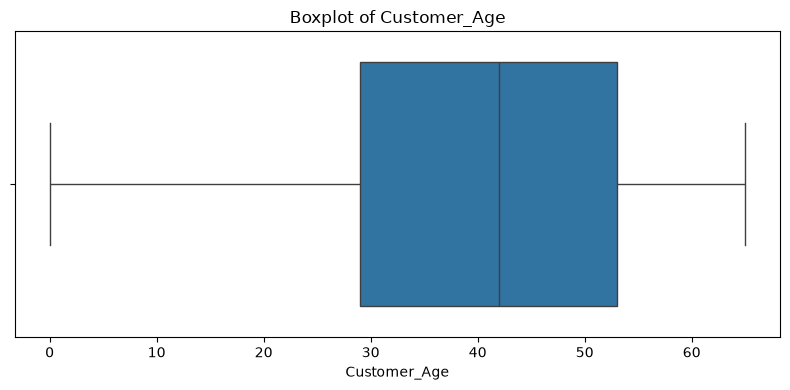

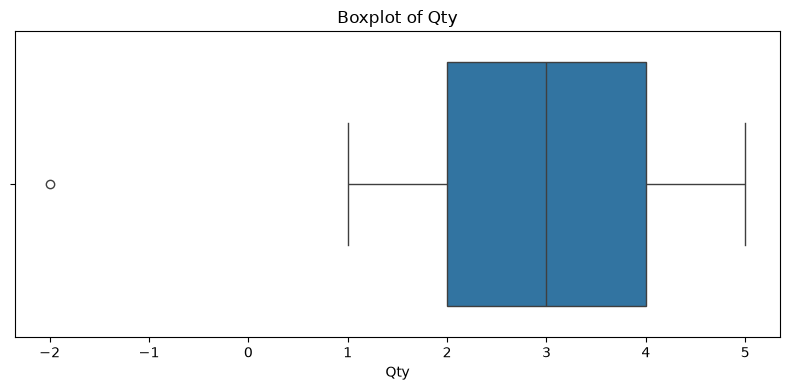

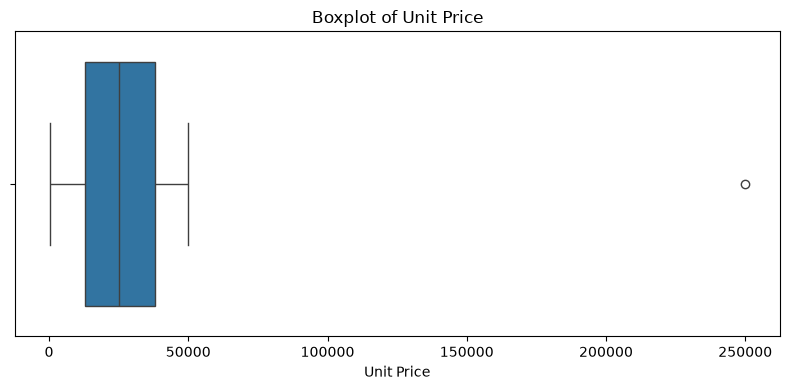

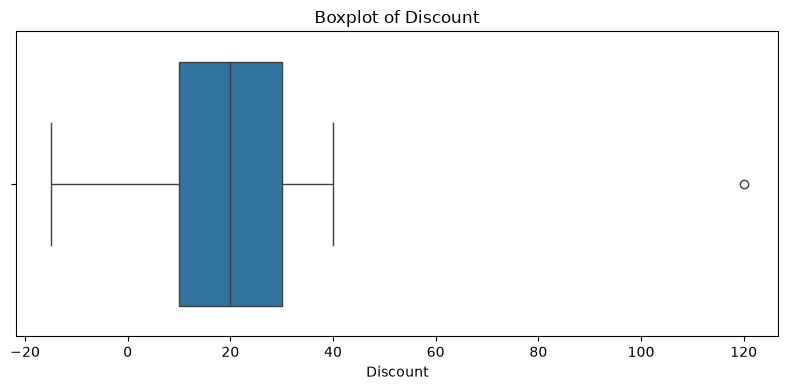

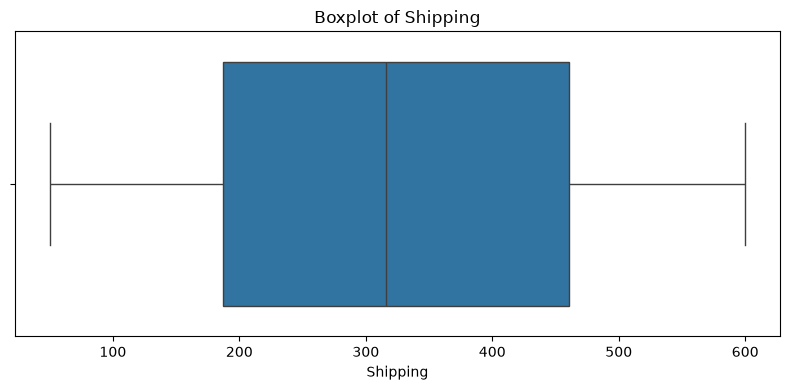

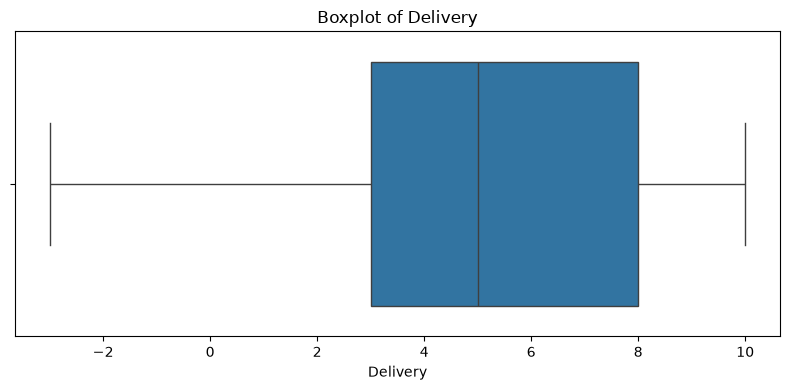

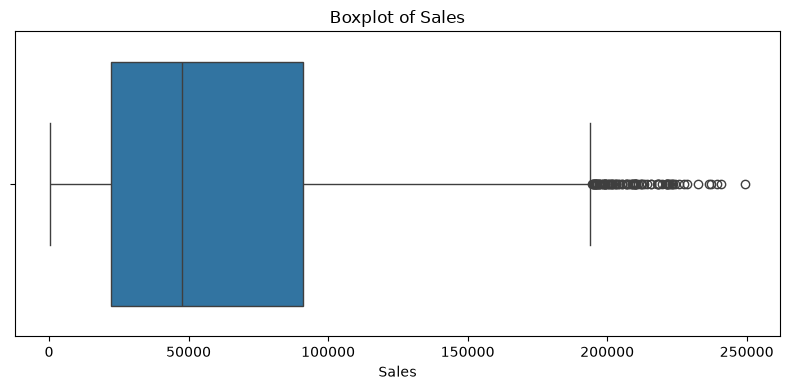

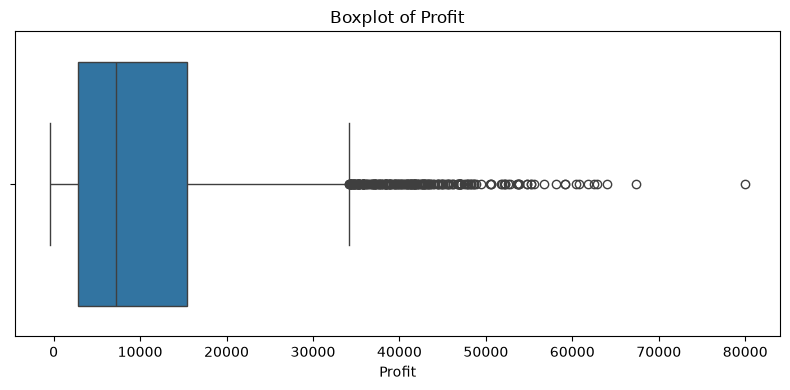

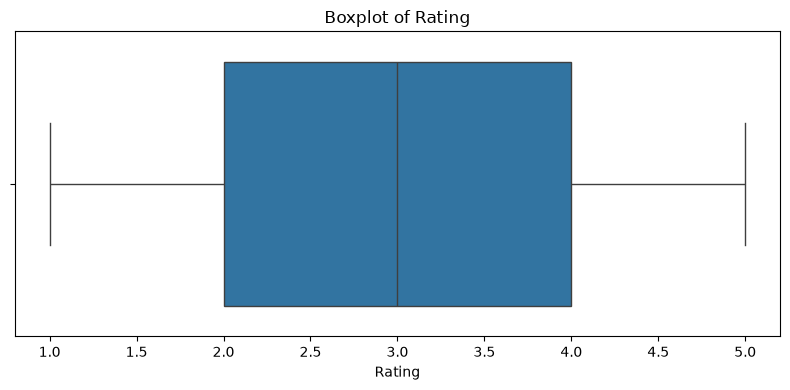

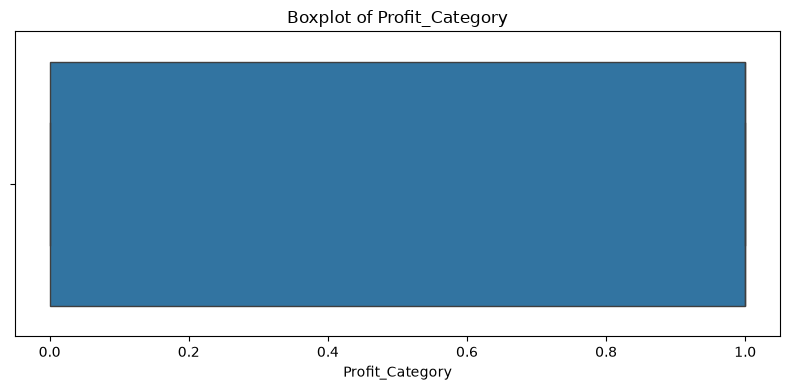

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column '{col}' - Total Outliers: {len(outliers)}")

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [8]:
import numpy as np
import pandas as pd

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.month
df["Year"] = df["Order_Date"].dt.year
df["Day_of_Week"] = df["Order_Date"].dt.day_name()
df["Is_Weekend"] = df["Order_Date"].dt.dayofweek.isin([5, 6]).astype(int)

df["Profit_Margin"] = np.where(df["Sales"] > 0, (df["Profit"] / df["Sales"]) * 100, 0)
df["Revenue_per_Item"] = np.where(df["Qty"] > 0, df["Sales"] / df["Qty"], 0)

In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df["Gender_Encoded"] = LabelEncoder().fit_transform(df["Gender"].astype(str))
df["Profit_Category_Encoded"] = LabelEncoder().fit_transform(
    df["Profit_Category"].astype(str)
)

df = pd.get_dummies(df, columns=["City", "Category"], drop_first=True)

In [10]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

scale_cols = ["Sales", "Profit", "Qty", "Unit Price"]

df_standard_scaled = df.copy()
df_standard_scaled[scale_cols] = scaler_standard.fit_transform(
    df[scale_cols]
)

df_minmax_scaled = df.copy()
df_minmax_scaled[scale_cols] = scaler_minmax.fit_transform(df[scale_cols])

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Profit_Category_Encoded"])
y = df["Profit_Category_Encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 1. Drop non-predictive identifier and target columns
cols_to_drop = ["Order_ID", "Order_Date", "Profit_Category_Encoded"]
if "Day_of_Week" in df.columns:
    cols_to_drop.append("Day_of_Week")

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df["Profit_Category_Encoded"]

# 2. Convert remaining categorical text into numeric indicators
X = pd.get_dummies(X, drop_first=True)

# 3. Fill missing values (NaN) across features
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# 4. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Fit models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score

# Step 11: Cross Validation (K-Fold)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    cv_results[name] = {
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std(),
    }

# Step 12: Hyperparameter Tuning (GridSearchCV)
param_grids = {
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5],
    },
}

tuned_models = {}
for name, grid in param_grids.items():
    grid_search = GridSearchCV(
        estimator=models[name],
        param_grid=grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    grid_search.fit(X_train, y_train)
    tuned_models[name] = grid_search.best_estimator_

# Step 13: Overfitting vs Underfitting Evaluation
fitting_evaluation = {}
for name, model in trained_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    diff = train_acc - test_acc

    if train_acc < 0.70 and test_acc < 0.70:
        status = "Underfitting (High Bias)"
    elif diff > 0.10:
        status = "Overfitting (High Variance)"
    else:
        status = "Well-Fitted"

    fitting_evaluation[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Difference": diff,
        "Status": status,
    }

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       259
           1       1.00      1.00      1.00       741

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



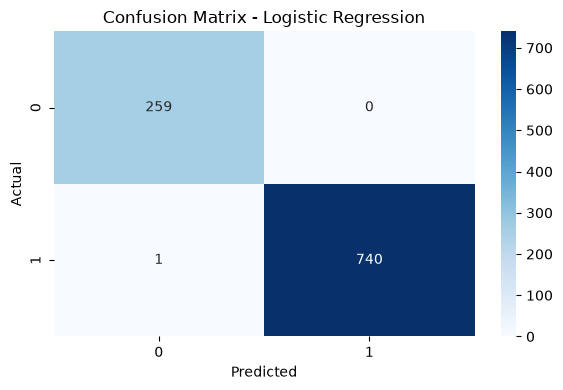

=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       259
           1       1.00      1.00      1.00       741

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



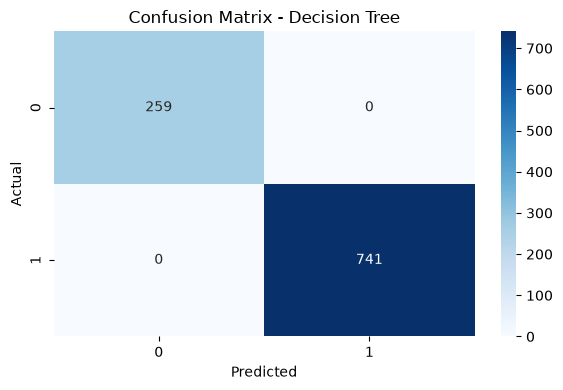

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       259
           1       1.00      1.00      1.00       741

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



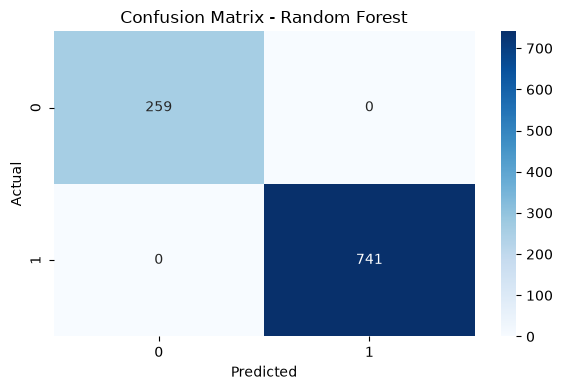

=== KNN Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       259
           1       0.98      0.98      0.98       741

    accuracy                           0.97      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.97      0.97      0.97      1000



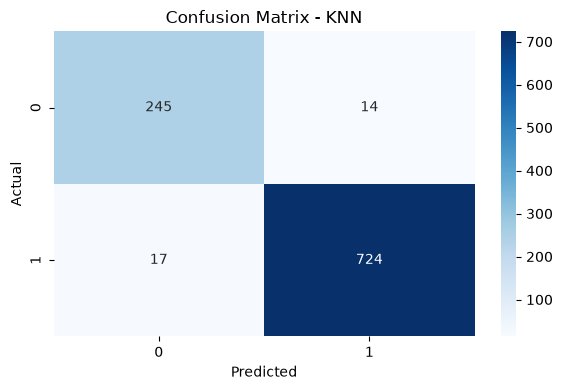

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       259
           1       0.95      0.96      0.96       741

    accuracy                           0.94      1000
   macro avg       0.92      0.91      0.92      1000
weighted avg       0.94      0.94      0.94      1000



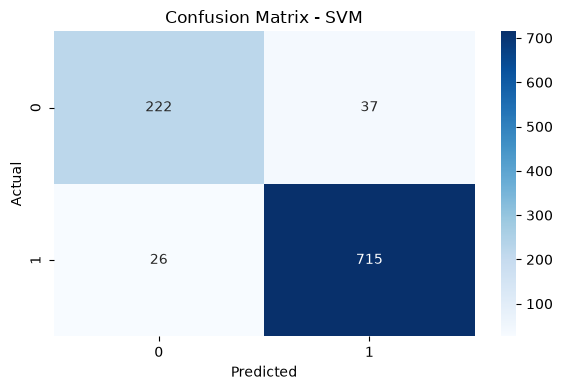

=== Gradient Boosting Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       259
           1       1.00      1.00      1.00       741

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



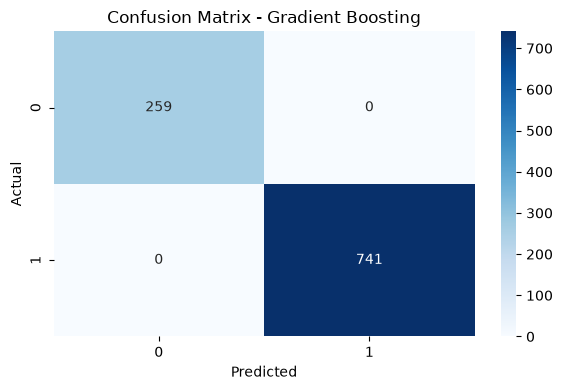

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

evaluation_results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        if y_prob.shape[1] == 2:
            roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
    else:
        roc_auc = None

    evaluation_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC": roc_auc,
    }

    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

C:\Users\Sachin\AppData\Local\Temp\ipykernel_16552\2903416996.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


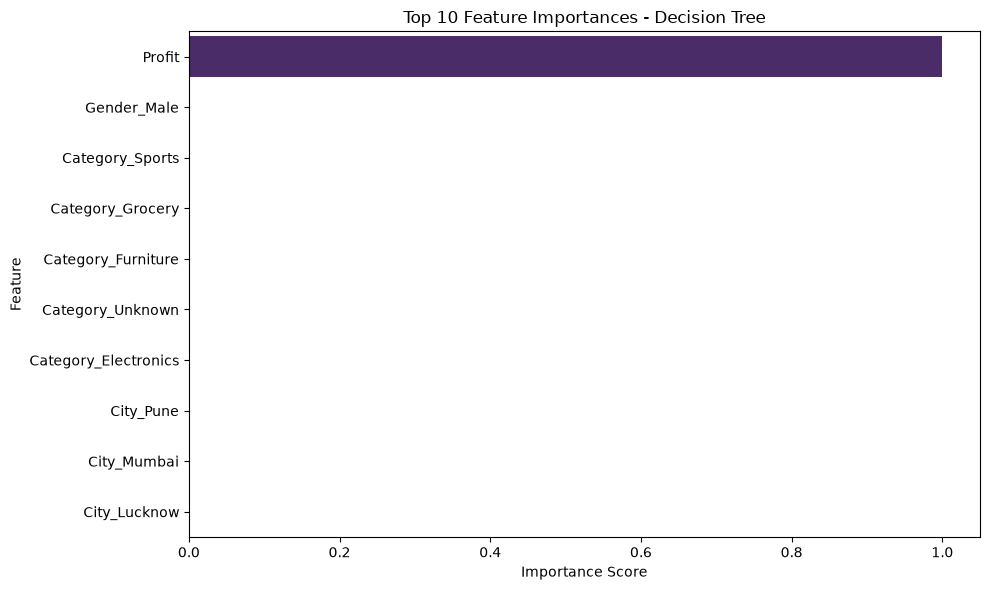

C:\Users\Sachin\AppData\Local\Temp\ipykernel_16552\2903416996.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


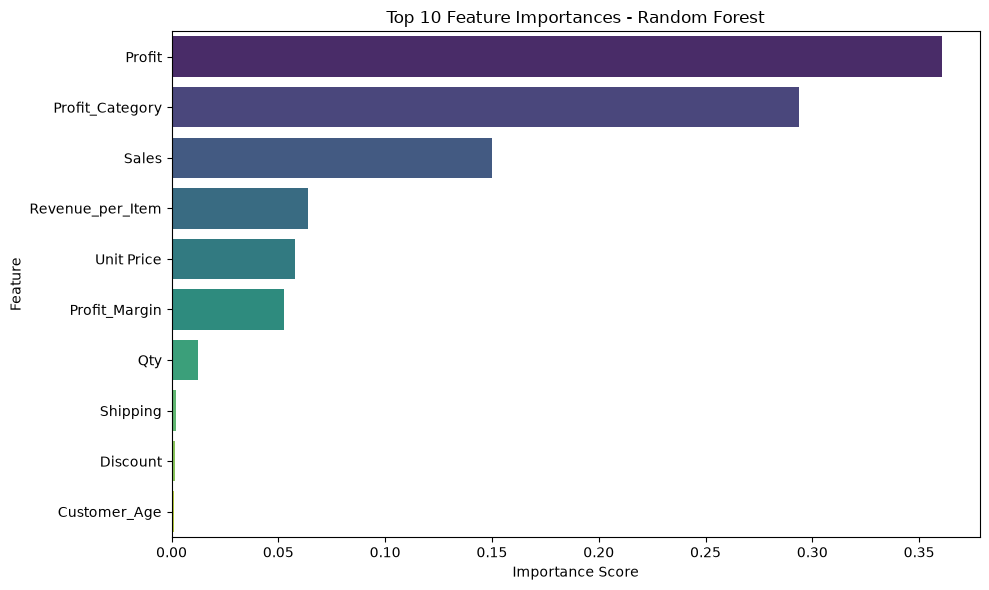

C:\Users\Sachin\AppData\Local\Temp\ipykernel_16552\2903416996.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


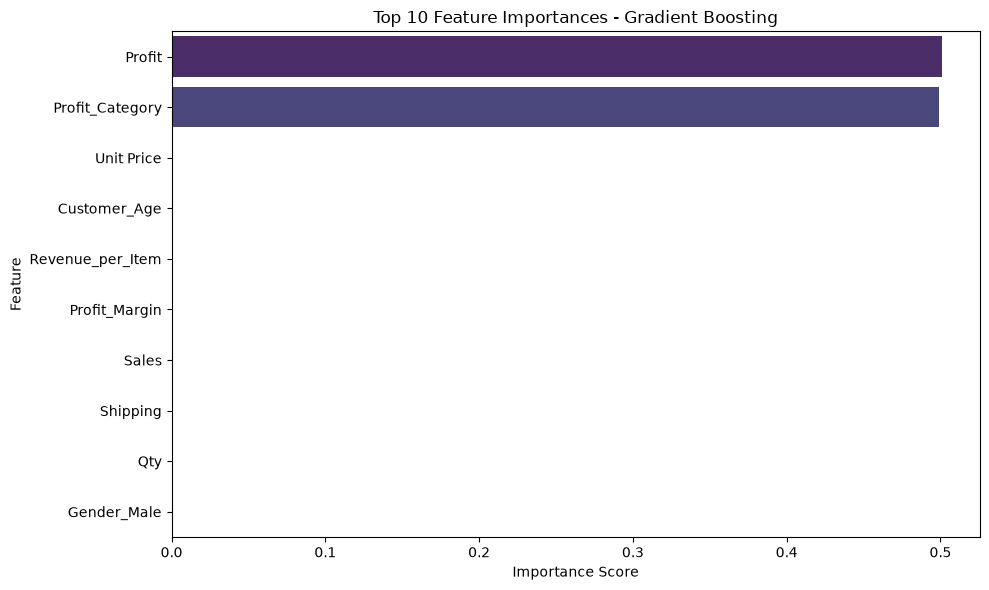

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

tree_models = {
    "Decision Tree": trained_models.get("Decision Tree"),
    "Random Forest": trained_models.get("Random Forest"),
    "Gradient Boosting": trained_models.get("Gradient Boosting"),
}

feature_names = X_train.columns

for name, model in tree_models.items():
    if model is not None and hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        importance_df = pd.DataFrame(
            {"Feature": feature_names[indices], "Importance": importances[indices]}
        )

        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=importance_df.head(10),
            x="Importance",
            y="Feature",
            palette="viridis",
        )
        plt.title(f"Top 10 Feature Importances - {name}")
        plt.xlabel("Importance Score")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

In [19]:
import joblib

best_model_name = max(
    evaluation_results, key=lambda k: evaluation_results[k]["Accuracy"]
)
best_model = trained_models[best_model_name]

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler_standard, "scaler.pkl")

['scaler.pkl']

In [20]:
import joblib
import numpy as np
import pandas as pd

new_data = pd.DataFrame(
    [
        {
            "Order_ID": "NEW001",
            "Order_Date": "2026-03-15",
            "Customer_Age": 34,
            "Gender": "Female",
            "City": "Nyc",
            "Category": "Electronics",
            "Qty": 2,
            "Sales": 1200.0,
            "Profit": 300.0,
            "Unit Price": 600.0,
        },
        {
            "Order_ID": "NEW002",
            "Order_Date": "2026-03-16",
            "Customer_Age": 52,
            "Gender": "Male",
            "City": "Us",
            "Category": "Clothing",
            "Qty": 10,
            "Sales": 50.0,
            "Profit": -10.0,
            "Unit Price": 5.0,
        },
    ]
)

loaded_model = joblib.load("best_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

new_data = new_data.replace(["?", "N/A", "-999", "null"], np.nan)
new_data.loc[new_data["Customer_Age"] < 0, "Customer_Age"] = np.nan
new_data.loc[new_data["Customer_Age"] > 120, "Customer_Age"] = np.nan

new_data["Order_Date"] = pd.to_datetime(
    new_data["Order_Date"], errors="coerce"
)
new_data["Month"] = new_data["Order_Date"].dt.month
new_data["Year"] = new_data["Order_Date"].dt.year
new_data["Is_Weekend"] = (
    new_data["Order_Date"].dt.dayofweek.isin([5, 6]).astype(int)
)

new_data["Profit_Margin"] = np.where(
    new_data["Sales"] > 0, (new_data["Profit"] / new_data["Sales"]) * 100, 0
)
new_data["Revenue_per_Item"] = np.where(
    new_data["Qty"] > 0, new_data["Sales"] / new_data["Qty"], 0
)

city_mapping = {
    "Nyc": "New York",
    "Ny": "New York",
    "Usa": "United States",
    "Us": "United States",
}
new_data["City"] = (
    new_data["City"].astype(str).str.strip().str.title().replace(city_mapping)
)
new_data["Category"] = (
    new_data["Category"].astype(str).str.strip().str.title()
)
new_data["Gender"] = new_data["Gender"].astype(str).str.strip().str.title()

cols_to_drop = ["Order_ID", "Order_Date"]
new_data_processed = new_data.drop(
    columns=[c for c in cols_to_drop if c in new_data.columns]
)

new_data_encoded = pd.get_dummies(new_data_processed, drop_first=True)

new_data_aligned = new_data_encoded.reindex(
    columns=X_train.columns, fill_value=0
)

num_cols = new_data_aligned.select_dtypes(include=[np.number]).columns
new_data_aligned[num_cols] = new_data_aligned[num_cols].fillna(
    X_train[num_cols].median()
)

scale_cols = [
    c for c in ["Sales", "Profit", "Qty", "Unit Price"] if c in scale_cols
]
new_data_aligned[scale_cols] = loaded_scaler.transform(
    new_data_aligned[scale_cols]
)

predictions = loaded_model.predict(new_data_aligned)
probabilities = (
    loaded_model.predict_proba(new_data_aligned)
    if hasattr(loaded_model, "predict_proba")
    else None
)

new_data["Predicted_Profit_Category_Encoded"] = predictions
if probabilities is not None:
    for i in range(probabilities.shape[1]):
        new_data[f"Probability_Class_{i}"] = probabilities[:, i]

print(
    new_data[
        [
            "Order_ID",
            "Sales",
            "Profit",
            "Profit_Margin",
            "Predicted_Profit_Category_Encoded",
        ]
    ]
)

  Order_ID   Sales  Profit  Profit_Margin  Predicted_Profit_Category_Encoded
0   NEW001  1200.0   300.0           25.0                                  0
1   NEW002    50.0   -10.0          -20.0                                  0
